In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('cars.csv')

In [4]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [7]:
df['brand'].value_counts()

brand
Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Ambassador          4
Kia                 4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64

In [9]:
df['brand'].nunique()

32

In [10]:
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [11]:
df['owner'].nunique()

5

In [12]:
df['fuel'].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [13]:
df['fuel'].nunique()

4

## 1. OneHotEncoding using Pandas

In [17]:
pd.get_dummies(df,columns=['fuel','owner']) # applying OHE on only the 'fuel' and 'owner' columns here
# This doesn't solve the problem of multicollinearity because drop_first=False by default so we used n columns instead of n-1

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


## 2. K-1 OneHotEncoding

In [18]:
pd.get_dummies(df,columns=['fuel','owner'],drop_first=True)
# drop_first=True drops the first column, so using n-1 columns only for each feature with n nominal categories - our problem of multicollinearity is solved

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


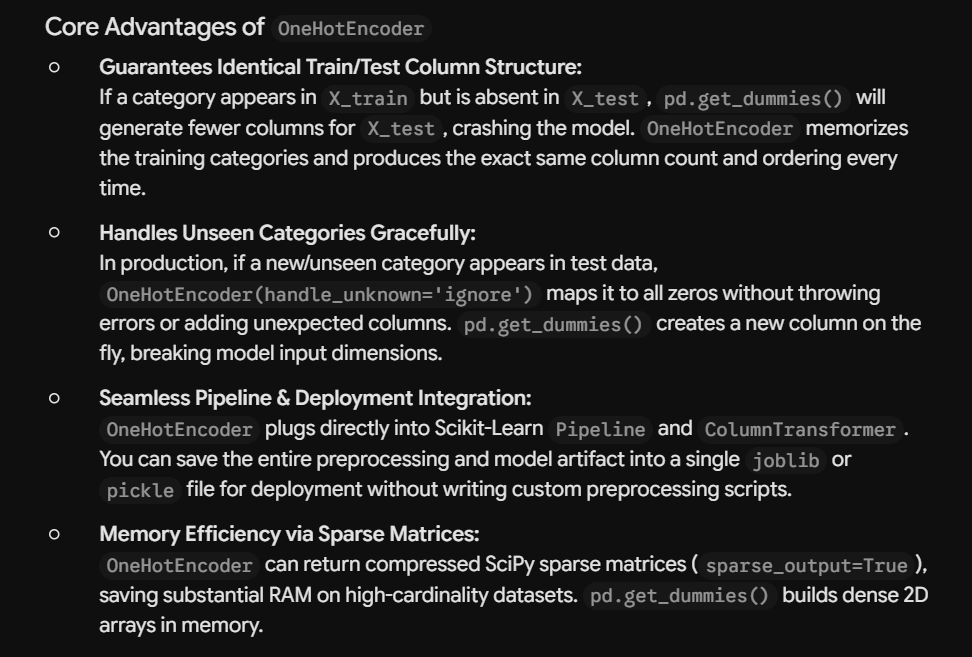

## 3. OneHotEncoding using Sklearn

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:4],df.iloc[:,-1],test_size=0.2,random_state=2)

In [20]:
X_train.head()

,brand,km_driven,fuel,owner
5571,Hyundai,35000,Diesel,First Owner
2038,Jeep,60000,Diesel,First Owner
2957,Hyundai,25000,Petrol,First Owner
7618,Mahindra,130000,Diesel,Second Owner
6684,Hyundai,155000,Diesel,First Owner


In [21]:
from sklearn.preprocessing import OneHotEncoder

In [29]:
ohe = OneHotEncoder(drop='first',sparse_output=False,dtype=np.int32)
# drop='first' se har feature ka first catefory hat jaayega
# sparse_output=False returns a NumPy array instead of a SciPy sparse matrix
# dtype=np.int32 stores encoded values cleanly as integers instead of the default floating point numbers

In [33]:
X_train_new = ohe.fit_transform(X_train[['fuel','owner']])

# extracting the two text columns and converting their categories into 0s/1s
# fit() looks at the training data to learn the unique categories and transform() actually overwrites them with binary numbers

In [34]:
X_test_new = ohe.transform(X_test[['fuel','owner']])

# applies the same 0/1 mapping to the test set

In [35]:
X_train_new.shape

(6502, 7)

In [36]:
# hstack() - horizontally stacks two tables side by side, it expects a tuple of lists where each list is the array which we wanna join with others
# .values() converts the dataframe into an array which is required by the hstack() function
np.hstack((X_train[['brand','km_driven']].values,X_train_new))

array([['Hyundai', 35000, 1, ..., 0, 0, 0],
       ['Jeep', 60000, 1, ..., 0, 0, 0],
       ['Hyundai', 25000, 0, ..., 0, 0, 0],
       ...,
       ['Tata', 15000, 0, ..., 0, 0, 0],
       ['Maruti', 32500, 1, ..., 1, 0, 0],
       ['Isuzu', 121000, 1, ..., 0, 0, 0]], shape=(6502, 9), dtype=object)

## 4. OneHotEncoding with Top Categories

In [47]:
counts = df['brand'].value_counts()

In [48]:
print(counts)

brand
Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Ambassador          4
Kia                 4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64


In [39]:
df['brand'].nunique()
threshold = 100 # we consider any brand <= 100 times in this dataset to be rare

In [49]:
repl = counts[counts <= threshold].index
# 'counts' variable stores the series where brand names is the index(key) and their numbers are the values
# if number<=100 it evaluates to True and we know that these are the uncommon brands and can be grouped together
# The concept used here is Boolean Indexing/Masking - entire dataset is evaluated at once on a mathematical condition and Pandas keeps only the ones which have 'True' and discards the 'False' ones
# .index strips away the values and keeps the keys only

In [56]:
pd.get_dummies(df['brand'].replace(repl, 'uncommon')).sample(5) # now we replace all the uncommon brands with a single 'uncommon' column

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
1901,False,False,False,False,False,False,False,False,False,False,False,False,True
5367,False,False,False,True,False,False,False,False,False,False,False,False,False
1545,False,False,False,False,False,False,True,False,False,False,False,False,False
7856,False,False,False,True,False,False,False,False,False,False,False,False,False
3311,False,False,False,False,False,False,False,False,False,False,False,False,True
